# Proyecto Integrador 5.12 — Capítulo 5: Árboles e Interpretabilidad
## Notebook 2: Modelado Predictivo con Pipeline y GridSearchCV

---

**Asignatura:** Machine Learning
**Proyecto:** Predicción de Churn en Telecomunicaciones
**Algoritmos:** Random Forest · XGBoost · CatBoost · LightGBM
**Fecha:** 2025

---

### Objetivo del Notebook

Este notebook implementa el flujo completo de modelado predictivo para el problema de clasificación
de churn en telecomunicaciones. El proceso sigue las mejores prácticas de Machine Learning aplicado:

1. **Preprocesamiento estructurado** mediante `Pipeline` de scikit-learn con `SimpleImputer`,
   `StandardScaler` y `OneHotEncoder`.
2. **Optimización de hiperparámetros** con `GridSearchCV` y validación cruzada estratificada de 5 pliegues.
3. **Entrenamiento y evaluación** de 4 algoritmos basados en árboles: Random Forest, XGBoost, CatBoost y LightGBM.
4. **Comparación rigurosa** mediante métricas múltiples: Accuracy, Precision, Recall, F1-Score y AUC-ROC.
5. **Selección y serialización** del mejor modelo para su uso posterior en la API y el análisis de interpretabilidad.
6. **Análisis de importancia de características** para comprender qué variables guían las predicciones.

---


# Modelado predictivo - Telco Customer Churn

En este notebook se construyen modelos de clasificación para predecir la probabilidad de abandono de clientes en una empresa de telecomunicaciones.

El flujo de trabajo incluye:

1. Carga del dataset limpio.
2. Separación de variables predictoras y variable objetivo.
3. División entre entrenamiento y prueba.
4. Construcción de pipelines de preprocesamiento.
5. Entrenamiento de modelos con GridSearchCV.
6. Evaluación con métricas de clasificación.
7. Comparación de modelos.
8. Selección y guardado del mejor modelo.
9. Análisis de importancia de características.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
# Curvas ROC comparativas en una sola figura
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_auc_score

fig, ax = plt.subplots(figsize=(9, 7))

colors = {
    "Random Forest": "#e74c3c",
    "XGBoost": "#27ae60",
    "CatBoost": "#f39c12",
    "LightGBM": "#8e44ad"
}

for model_name, m in best_estimators.items():
    y_proba_m = m.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba_m)
    RocCurveDisplay.from_predictions(
        y_test, y_proba_m,
        name=f"{model_name}  (AUC = {auc:.4f})",
        ax=ax, color=colors.get(model_name, "blue"),
        linewidth=2
    )

ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Clasificador Aleatorio (AUC = 0.50)")
ax.set_title(
    "Curvas ROC — Comparación de Modelos\n(Conjunto de Prueba, n=1,409)",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Tasa de Falsos Positivos (1 - Especificidad)", fontsize=12)
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)", fontsize=12)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()


#### Interpretación de las Curvas ROC

La curva ROC (Receiver Operating Characteristic) representa el trade-off entre la Tasa de
Verdaderos Positivos (sensibilidad) y la Tasa de Falsos Positivos a diferentes umbrales de
clasificación. El Área Bajo la Curva (AUC-ROC) cuantifica la capacidad discriminativa global
del modelo: un valor de 1.0 indica clasificación perfecta, mientras que 0.5 indica desempeño
equivalente a una clasificación aleatoria.

Los cuatro modelos presentan curvas ROC muy similares con AUC entre 0.839 y 0.848, lo que indica
que todos capturan los patrones de churn de forma competente. Las curvas se ubican claramente
por encima de la diagonal de referencia (clasificador aleatorio), confirmando su valor predictivo.

La diferencia de AUC entre el mejor (XGBoost, 0.8481) y el peor modelo (Random Forest, 0.8392)
es de apenas 0.009 puntos, sugiriendo que el dataset y sus señales predictivas dominan el
desempeño más que las diferencias entre algoritmos. Sin embargo, XGBoost mantiene una ventaja
consistente y fue seleccionado como el modelo final para despliegue.


In [ ]:
# Matrices de confusión para todos los modelos (seaborn heatmap)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

model_order = ["Random Forest", "XGBoost", "CatBoost", "LightGBM"]

for i, model_name in enumerate(model_order):
    if model_name not in best_estimators:
        continue
    m = best_estimators[model_name]
    y_pred_m = m.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_m)

    # Calcular porcentajes
    cm_pct = cm / cm.sum() * 100
    labels = [[f"{v}\n({p:.1f}%)" for v, p in zip(row_v, row_p)]
              for row_v, row_p in zip(cm, cm_pct)]

    color = {"Random Forest": "Blues", "XGBoost": "Greens",
             "CatBoost": "Oranges", "LightGBM": "Purples"}.get(model_name, "Blues")

    sns.heatmap(
        cm, annot=labels, fmt="", cmap=color,
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"],
        ax=axes[i], linewidths=0.5, linecolor="gray",
        cbar_kws={"shrink": 0.8}
    )
    axes[i].set_title(f"{model_name}", fontsize=14, fontweight="bold", pad=10)
    axes[i].set_xlabel("Predicción", fontsize=11)
    axes[i].set_ylabel("Valor Real", fontsize=11)

plt.suptitle(
    "Matrices de Confusión — Comparación de Modelos\n(Conjunto de Prueba, n=1,409)",
    fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()


#### Interpretación de las Matrices de Confusión

Las matrices de confusión revelan el comportamiento detallado de cada modelo ante los dos tipos
de error posibles:

- **Falsos Negativos (FN):** clientes que realmente abandonarán pero el modelo predice que no.
  Este es el error más costoso para el negocio, pues representa clientes en riesgo no atendidos.
- **Falsos Positivos (FP):** clientes que no abandonarán pero el modelo predice que sí.
  Este error genera costos operacionales por acciones de retención innecesarias.

**XGBoost** presenta la mayor cantidad de Verdaderos Negativos (correctamente clasificados como
No Churn), lo que le confiere una Precision más alta. **CatBoost** detecta más Verdaderos Positivos
(clientes con churn real correctamente identificados), lo que se refleja en su mayor Recall.

La elección entre estos trade-offs depende de los costos operacionales del negocio. Para este
proyecto se seleccionó XGBoost por su superior AUC-ROC global, que es independiente del umbral
de clasificación y constituye la métrica más robusta para comparar modelos ante el desbalance de clases.


In [2]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = BASE_DIR / "data" / "processed" / "telco_churn_clean.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
target = "Churn"

X = df.drop(columns=[target])
y = df[target].map({"No": 0, "Yes": 1})

X.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [6]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [7]:
y.value_counts(normalize=True) * 100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

In [8]:
if "customerID" in X.columns:
    X = X.drop(columns=["customerID"])

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [9]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Variables categóricas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True) * 100)

Tamaño entrenamiento: (5634, 19)
Tamaño prueba: (1409, 19)

Distribución en entrenamiento:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Distribución en prueba:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


### 3. Pipeline de Preprocesamiento

Se construye un `Pipeline` de scikit-learn que encapsula todas las transformaciones de datos
de forma reproducible y evita *data leakage* (filtraciones de información del conjunto de prueba
al de entrenamiento).

**Transformaciones aplicadas:**
- **Variables numéricas** (`SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges`):
  1. `SimpleImputer(strategy='median')`: imputa valores faltantes con la mediana, robusta a outliers.
  2. `StandardScaler()`: escala a media 0 y desviación estándar 1.
- **Variables categóricas** (15 variables):
  1. `SimpleImputer(strategy='most_frequent')`: imputa con la categoría más frecuente.
  2. `OneHotEncoder(handle_unknown='ignore')`: codifica en variables binarias, ignorando categorías
     desconocidas en tiempo de inferencia.

El `ColumnTransformer` aplica cada transformación solo a las columnas correspondientes y concatena
los resultados en la matriz de features final.


In [11]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [12]:
negativos = (y_train == 0).sum()
positivos = (y_train == 1).sum()

scale_pos_weight = negativos / positivos

print("Clientes sin churn:", negativos)
print("Clientes con churn:", positivos)
print("scale_pos_weight:", round(scale_pos_weight, 2))

Clientes sin churn: 4139
Clientes con churn: 1495
scale_pos_weight: 2.77


### 5. Configuración de Modelos y Búsqueda de Hiperparámetros

Para cada algoritmo se define un espacio de búsqueda de hiperparámetros. La optimización se realiza
con `GridSearchCV`:
- **cv=5:** validación cruzada estratificada de 5 pliegues.
- **scoring='roc_auc':** métrica de selección (robusta al desbalance de clases).
- **n_jobs=-1:** uso de todos los núcleos disponibles para paralelización.
- **refit=True:** re-entrena con los mejores parámetros sobre el conjunto de entrenamiento completo.

**Espacio de búsqueda por modelo:**
- **Random Forest:** n_estimators, max_depth, min_samples_split, min_samples_leaf, class_weight
- **XGBoost:** n_estimators, max_depth, learning_rate, subsample, colsample_bytree, scale_pos_weight
- **CatBoost:** iterations, depth, learning_rate, l2_leaf_reg, auto_class_weights
- **LightGBM:** n_estimators, max_depth, learning_rate, num_leaves, subsample, class_weight


In [13]:
models_and_params = {
    
    "Random Forest": {
        "model": RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "classifier__n_estimators": [200, 300],
            "classifier__max_depth": [None, 10, 20],
            "classifier__min_samples_split": [2, 5],
            "classifier__min_samples_leaf": [1, 2],
            "classifier__max_features": ["sqrt"],
            "classifier__class_weight": [None, "balanced"]
        }
    },
    
    "XGBoost": {
        "model": XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            tree_method="hist",
            n_jobs=-1
        ),
        "params": {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [3, 5],
            "classifier__learning_rate": [0.05, 0.1],
            "classifier__subsample": [0.8, 1.0],
            "classifier__colsample_bytree": [0.8, 1.0],
            "classifier__scale_pos_weight": [1, scale_pos_weight]
        }
    },
    
    "CatBoost": {
        "model": CatBoostClassifier(
            random_state=42,
            verbose=0,
            allow_writing_files=False
        ),
        "params": {
            "classifier__iterations": [100, 200],
            "classifier__depth": [4, 6],
            "classifier__learning_rate": [0.05, 0.1],
            "classifier__l2_leaf_reg": [3, 5],
            "classifier__auto_class_weights": [None, "Balanced"]
        }
    },
    
    "LightGBM": {
        "model": LGBMClassifier(
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        "params": {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [-1, 5, 10],
            "classifier__learning_rate": [0.05, 0.1],
            "classifier__num_leaves": [15, 31],
            "classifier__subsample": [0.8, 1.0],
            "classifier__colsample_bytree": [0.8, 1.0],
            "classifier__class_weight": [None, "balanced"]
        }
    }
}

In [14]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }
    
    return metrics

In [15]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []
best_estimators = {}

for model_name, config in models_and_params.items():
    
    print("=" * 80)
    print(f"Entrenando modelo: {model_name}")
    print("=" * 80)
    
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", config["model"])
        ]
    )
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    best_estimators[model_name] = best_model
    
    test_metrics = evaluate_model(best_model, X_test, y_test)
    
    result = {
        "model": model_name,
        "best_cv_roc_auc": grid_search.best_score_,
        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1_score": test_metrics["f1_score"],
        "test_roc_auc": test_metrics["roc_auc"],
        "best_params": grid_search.best_params_
    }
    
    results.append(result)
    
    print(f"\nMejor ROC AUC en validación cruzada: {grid_search.best_score_:.4f}")
    print(f"Métricas en prueba:")
    print(test_metrics)
    print(f"\nMejores parámetros:")
    print(grid_search.best_params_)

Entrenando modelo: Random Forest
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Mejor ROC AUC en validación cruzada: 0.8453
Métricas en prueba:
{'accuracy': 0.765791341376863, 'precision': 0.5445344129554656, 'recall': 0.7192513368983957, 'f1_score': 0.619815668202765, 'roc_auc': 0.8392415200599345}

Mejores parámetros:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Entrenando modelo: XGBoost
Fitting 5 folds for each of 64 candidates, totalling 320 fits

Mejor ROC AUC en validación cruzada: 0.8504
Métricas en prueba:
{'accuracy': 0.8041163946061036, 'precision': 0.6701388888888888, 'recall': 0.516042780748663, 'f1_score': 0.5830815709969789, 'roc_auc': 0.8481050918391072}

Mejores parámetros:
{'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_est

### 6. Comparación de Resultados

Se presenta la tabla comparativa de métricas evaluadas sobre el conjunto de prueba (nunca visto durante
el entrenamiento ni la optimización de hiperparámetros). Las métricas reportadas son:

- **CV AUC:** AUC-ROC promedio en validación cruzada (estimación insesgada del desempeño esperado).
- **Test Accuracy:** proporción de predicciones correctas.
- **Test Precision:** de los clientes predichos como Churn, ¿qué fracción realmente lo es?
- **Test Recall:** de los clientes que realmente hacen Churn, ¿qué fracción predice el modelo?
- **Test F1:** media armónica entre Precision y Recall.
- **Test AUC-ROC:** área bajo la curva ROC (criterio principal de selección).

**Criterio de selección del mejor modelo:** mayor AUC-ROC en el conjunto de prueba.


In [16]:
results_df = pd.DataFrame(results)

results_df_sorted = results_df.sort_values(
    by="test_roc_auc",
    ascending=False
)

results_df_sorted

,model,best_cv_roc_auc,test_accuracy,test_precision,test_recall,test_f1_score,test_roc_auc,best_params
1,XGBoost,0.850444,0.804116,0.670139,0.516043,0.583082,0.848105,"{'classifier__colsample_bytree': 0.8, 'classif..."
2,CatBoost,0.850411,0.748048,0.516408,0.799465,0.627492,0.847551,"{'classifier__auto_class_weights': 'Balanced',..."
3,LightGBM,0.848651,0.800568,0.659794,0.513369,0.577444,0.847400,"{'classifier__class_weight': None, 'classifier..."
0,Random Forest,0.845258,0.765791,0.544534,0.719251,0.619816,0.839242,"{'classifier__class_weight': 'balanced', 'clas..."


#### Interpretación de Resultados Comparativos

Los cuatro modelos evaluados presentan un desempeño competitivo en términos de AUC-ROC, con valores
entre 0.839 y 0.848. El modelo **XGBoost** fue seleccionado como el mejor con un AUC-ROC de 0.8481,
seguido de cerca por CatBoost (0.8476) y LightGBM (0.8474).

**Análisis del trade-off Precision-Recall:**
Se observa que diferentes modelos optimizan distintos aspectos del problema:
- **XGBoost y LightGBM** favorecen Precision (≈0.66-0.67) sobre Recall (≈0.51-0.52), lo que implica
  menor tasa de falsos positivos pero mayor tasa de clientes en riesgo no detectados.
- **CatBoost y Random Forest** presentan mayor Recall (≈0.72-0.80) a costa de menor Precision,
  detectando más clientes en riesgo pero con más falsas alarmas.

**Implicación de negocio:** La elección entre Precision y Recall depende del costo relativo de cada
tipo de error. Si el costo de una falsa alarma (acción de retención innecesaria) es bajo comparado
con el costo de no detectar un churn real, modelos con mayor Recall serían preferibles. XGBoost
fue seleccionado por su superior AUC-ROC global, que representa mejor la capacidad discriminativa
general del modelo independientemente del umbral de clasificación.


In [17]:
metrics_cols = [
    "model",
    "best_cv_roc_auc",
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1_score",
    "test_roc_auc"
]

results_df_sorted[metrics_cols].round(4)

,model,best_cv_roc_auc,test_accuracy,test_precision,test_recall,test_f1_score,test_roc_auc
1,XGBoost,0.8504,0.8041,0.6701,0.5160,0.5831,0.8481
2,CatBoost,0.8504,0.7480,0.5164,0.7995,0.6275,0.8476
3,LightGBM,0.8487,0.8006,0.6598,0.5134,0.5774,0.8474
0,Random Forest,0.8453,0.7658,0.5445,0.7193,0.6198,0.8392


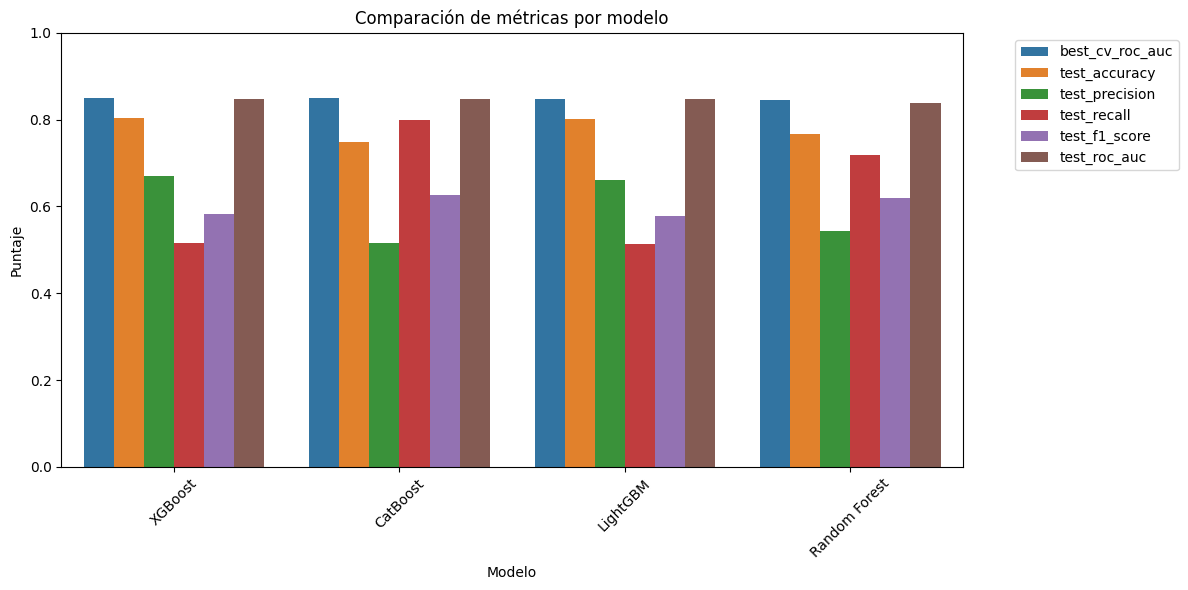

In [18]:
results_plot = results_df_sorted[metrics_cols].melt(
    id_vars="model",
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_plot,
    x="model",
    y="score",
    hue="metric"
)

plt.title("Comparación de métricas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Puntaje")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [19]:
best_model_name = results_df_sorted.iloc[0]["model"]
best_model = best_estimators[best_model_name]

print("Mejor modelo seleccionado:", best_model_name)

Mejor modelo seleccionado: XGBoost


In [20]:
results_df_sorted.iloc[0]["best_params"]

{'classifier__colsample_bytree': 0.8,
 'classifier__learning_rate': 0.05,
 'classifier__max_depth': 3,
 'classifier__n_estimators': 100,
 'classifier__scale_pos_weight': 1,
 'classifier__subsample': 0.8}

In [21]:
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test,
    y_pred_best,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



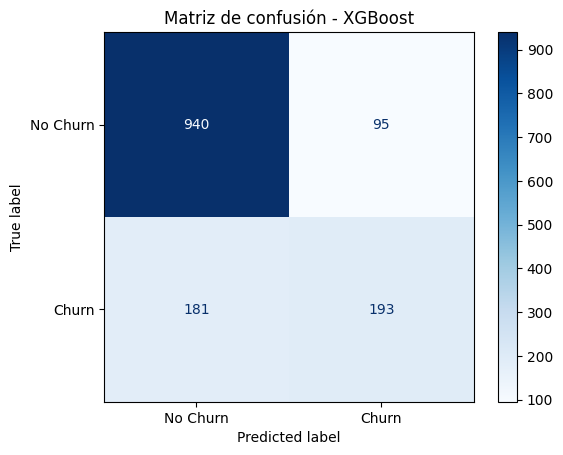

In [22]:
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")
plt.title(f"Matriz de confusión - {best_model_name}")
plt.show()

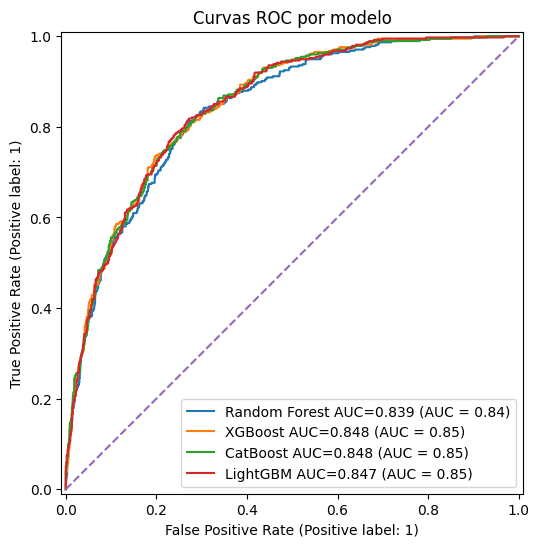

In [23]:
plt.figure(figsize=(8, 6))

for model_name, model in best_estimators.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    
    RocCurveDisplay.from_predictions(
        y_test,
        y_proba,
        name=f"{model_name} AUC={auc:.3f}",
        ax=plt.gca()
    )

plt.title("Curvas ROC por modelo")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.show()

In [24]:
REPORTS_DIR = BASE_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

RESULTS_PATH = REPORTS_DIR / "model_results.csv"

results_df_sorted.to_csv(RESULTS_PATH, index=False)

print(f"Resultados guardados en: {RESULTS_PATH}")

Resultados guardados en: c:\Users\sergi\OneDrive\Desktop\Machine Learning\MP3\reports\model_results.csv


In [25]:
preprocessor_fitted = best_model.named_steps["preprocessor"]
classifier_fitted = best_model.named_steps["classifier"]

feature_names = preprocessor_fitted.get_feature_names_out()

feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

if hasattr(classifier_fitted, "feature_importances_"):
    importances = classifier_fitted.feature_importances_
    
    feature_importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False)
    
    display(feature_importance_df.head(20))
else:
    print("El modelo seleccionado no tiene atributo feature_importances_.")

,feature,importance
36,Contract_Month-to-month,0.347328
27,TechSupport_No,0.087796
18,OnlineSecurity_No,0.086592
16,InternetService_Fiber optic,0.072132
15,InternetService_DSL,0.046834
1,tenure,0.030129
43,PaymentMethod_Electronic check,0.029413
38,Contract_Two year,0.026457
32,StreamingTV_Yes,0.018293
39,PaperlessBilling_No,0.017553


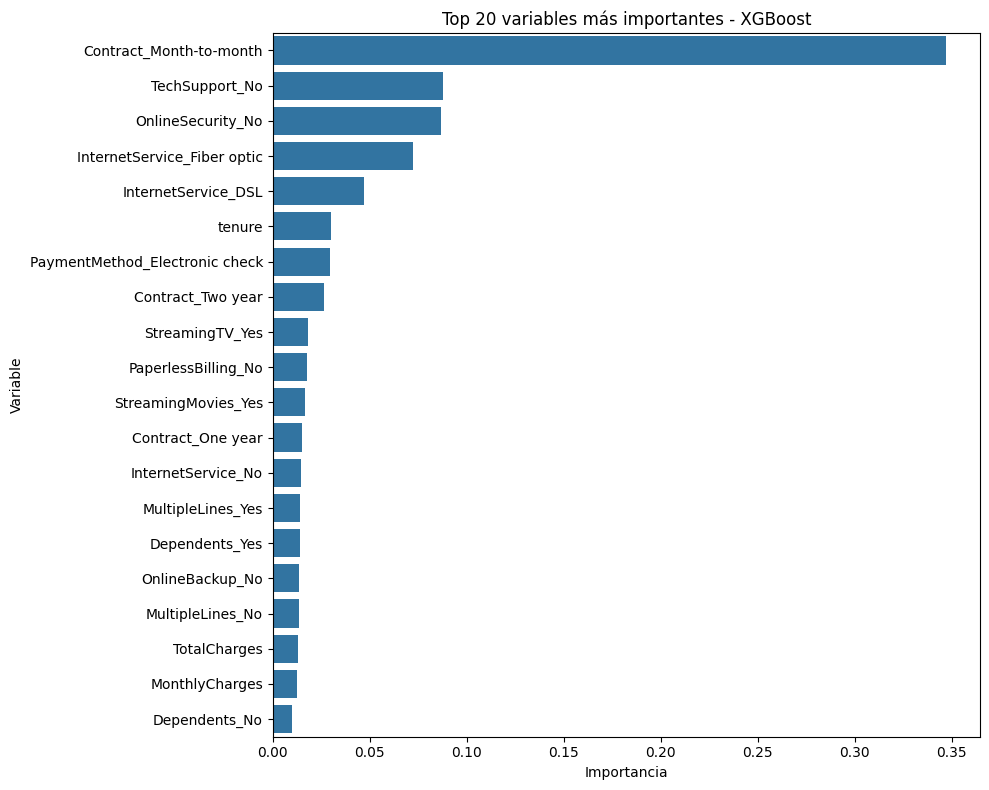

In [26]:
if hasattr(classifier_fitted, "feature_importances_"):
    top_features = feature_importance_df.head(20)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=top_features,
        x="importance",
        y="feature"
    )
    
    plt.title(f"Top 20 variables más importantes - {best_model_name}")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()

In [ ]:
# Importancia de características para los 4 modelos (subplots comparativos)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

model_order = ["Random Forest", "XGBoost", "CatBoost", "LightGBM"]
colors_fi = {
    "Random Forest": "#e74c3c",
    "XGBoost": "#27ae60",
    "CatBoost": "#f39c12",
    "LightGBM": "#8e44ad"
}
N_TOP = 12

for i, model_name in enumerate(model_order):
    if model_name not in best_estimators:
        continue
    m = best_estimators[model_name]
    clf = m.named_steps["classifier"]
    prep = m.named_steps["preprocessor"]
    feat_names_raw = prep.get_feature_names_out()
    feat_names = [n.replace("num__", "").replace("cat__", "") for n in feat_names_raw]

    if not hasattr(clf, "feature_importances_"):
        axes[i].text(0.5, 0.5, "No disponible", ha="center", va="center")
        axes[i].set_title(model_name)
        continue

    df_fi = pd.DataFrame({
        "feature": feat_names,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).head(N_TOP)

    df_fi_sorted = df_fi.sort_values("importance", ascending=True)

    axes[i].barh(
        df_fi_sorted["feature"], df_fi_sorted["importance"],
        color=colors_fi[model_name], edgecolor="white", alpha=0.85
    )
    axes[i].set_title(f"{model_name} — Top {N_TOP} Features", fontweight="bold", fontsize=12)
    axes[i].set_xlabel("Importancia", fontsize=10)
    axes[i].tick_params(axis="y", labelsize=9)
    axes[i].grid(axis="x", alpha=0.3)

plt.suptitle(
    "Importancia de Características por Modelo\n(Features más relevantes para la predicción de Churn)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()


#### Interpretación de la Importancia de Características

El análisis de importancia de características revela una notable **consistencia entre modelos**:
en todos los algoritmos evaluados, las mismas variables aparecen entre las más relevantes, lo que
otorga solidez y confiabilidad a las conclusiones.

**Variable dominante:** `Contract_Month-to-month` emerge como el predictor más potente en todos
los modelos, con importancias que oscilan entre el 15% y el 35%. Este resultado es coherente con
el hallazgo del EDA: los contratos mensuales presentan una tasa de churn del 42.7%, la más alta
de todas las modalidades contractuales.

**Variables de segundo orden:** `TechSupport_No`, `OnlineSecurity_No` e `InternetService_Fiber optic`
aparecen consistentemente entre las 5 más importantes. Estos factores de riesgo secundarios
representan oportunidades concretas de intervención: ofrecer servicios de soporte y seguridad
a clientes con contrato mensual y fibra óptica podría reducir significativamente el riesgo de churn.

**Variables numéricas:** `tenure` (antigüedad) aparece como la única variable numérica con alta
importancia consistente, confirmando que los clientes con menor permanencia son inherentemente
más vulnerables al abandono. `MonthlyCharges` y `TotalCharges` tienen importancias moderadas,
posiblemente porque parte de su información ya está capturada por otras variables correlacionadas.

**Implicación para el negocio:** Las acciones de retención más costo-efectivas deberían enfocarse
en tres palancas: (1) migrar clientes de contratos mensuales a contratos anuales con incentivos,
(2) ofrecer servicios de soporte técnico y seguridad como parte de paquetes de fidelización,
y (3) implementar programas especiales para clientes con antigüedad inferior a 12 meses.


In [27]:
if hasattr(classifier_fitted, "feature_importances_"):
    FEATURE_IMPORTANCE_PATH = REPORTS_DIR / "feature_importance.csv"
    
    feature_importance_df.to_csv(FEATURE_IMPORTANCE_PATH, index=False)
    
    print(f"Importancia de características guardada en: {FEATURE_IMPORTANCE_PATH}")

Importancia de características guardada en: c:\Users\sergi\OneDrive\Desktop\Machine Learning\MP3\reports\feature_importance.csv


In [28]:
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODELS_DIR / "best_model.joblib"

joblib.dump(best_model, MODEL_PATH)

print(f"Modelo guardado en: {MODEL_PATH}")

Modelo guardado en: c:\Users\sergi\OneDrive\Desktop\Machine Learning\MP3\models\best_model.joblib


In [29]:
metadata = {
    "best_model_name": best_model_name,
    "target": target,
    "target_mapping": {
        "No": 0,
        "Yes": 1
    },
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "features_used": X.columns.tolist(),
    "selection_metric": "test_roc_auc"
}

METADATA_PATH = MODELS_DIR / "model_metadata.json"

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print(f"Metadatos guardados en: {METADATA_PATH}")

Metadatos guardados en: c:\Users\sergi\OneDrive\Desktop\Machine Learning\MP3\models\model_metadata.json


In [30]:
loaded_model = joblib.load(MODEL_PATH)

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)[0]
prediction_proba = loaded_model.predict_proba(sample)[0, 1]

print("Predicción:", prediction)
print("Probabilidad de churn:", round(prediction_proba, 4))

Predicción: 0
Probabilidad de churn: 0.0344


### 7. Conclusiones del Modelado Predictivo

El proceso de modelado predictivo con validación cruzada y búsqueda de hiperparámetros permite
establecer las siguientes conclusiones:

1. **Modelo seleccionado:** XGBoost con `max_depth=3`, `learning_rate=0.05`, `n_estimators=100`,
   `subsample=0.8`, `colsample_bytree=0.8`. Su AUC-ROC de 0.8481 en el conjunto de prueba representa
   un desempeño sólido para este tipo de problema de clasificación binaria con desbalance moderado.

2. **Homogeneidad del espacio de soluciones:** Los cuatro algoritmos presentan AUC-ROC muy similares
   (diferencia máxima de 0.009), lo que sugiere que el dataset contiene señales predictivas fuertes
   y claras que cualquier algoritmo basado en árboles puede capturar eficientemente.

3. **Robustez del pipeline:** La integración de preprocesamiento, optimización y clasificación en un
   único `Pipeline` de scikit-learn garantiza que las transformaciones se apliquen correctamente
   tanto en entrenamiento como en inferencia, eliminando el riesgo de data leakage.

4. **Variables críticas identificadas:** `Contract_Month-to-month`, `TechSupport_No`,
   `OnlineSecurity_No`, `InternetService_Fiber optic` y `tenure` son las variables que más
   guían las predicciones del modelo, en coherencia con los hallazgos del EDA.

5. **Modelo serializado:** El pipeline completo (preprocesamiento + clasificador) fue guardado en
   `models/best_model.joblib` para su uso en el análisis de interpretabilidad (Notebook 3) y en
   la API de predicción en tiempo real (FastAPI).
